# Car Market Trends Analysis — CarDekho Dataset
## DIY Project | VOIS for Tech Data Analytics Program

**Objective:** To analyse used car market trends using the CarDekho dataset,
identifying key factors that influence resale price, depreciation, and
market demand across fuel types, transmission types, and car age.

**Dataset:** 301 records, 9 columns covering car name, year, selling price,
present price, kilometres driven, fuel type, seller type, transmission,
and number of previous owners.

**Tools Used:** Python (pandas, numpy, matplotlib, seaborn) | Google Colab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Car Market Trends Analysis with Car Dekho Data.csv')

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe(include= 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [ ]:
print('Duplicates found:', df.duplicated().sum())
df = df.drop_duplicates().copy()
print('Duplicates remaining:', df.duplicated().sum())

Duplicates found: 2
Duplicates remaining: 0


In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})
print(missing)

               Missing Count  Missing %
Car_Name                   0        0.0
Year                       0        0.0
Selling_Price              0        0.0
Present_Price              0        0.0
Kms_Driven                 0        0.0
Fuel_Type                  0        0.0
Seller_Type                0        0.0
Transmission               0        0.0
Owner                      0        0.0


In [ ]:
df['Car_Age'] = 2025 - df['Year']
print(df['Car_Age'].describe())

count    299.000000
mean      11.384615
std        2.896868
min        7.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       22.000000
Name: Car_Age, dtype: float64


In [ ]:
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_%'] = ((df['Depreciation'] / df['Present_Price']) * 100).round(2)
print(df[['Car_Name', 'Present_Price', 'Selling_Price', 'Depreciation', 'Depreciation_%']].head(10))

        Car_Name  Present_Price  Selling_Price  Depreciation  Depreciation_%
0           ritz           5.59           3.35          2.24           40.07
1            sx4           9.54           4.75          4.79           50.21
2           ciaz           9.85           7.25          2.60           26.40
3        wagon r           4.15           2.85          1.30           31.33
4          swift           6.87           4.60          2.27           33.04
5  vitara brezza           9.83           9.25          0.58            5.90
6           ciaz           8.12           6.75          1.37           16.87
7        s cross           8.61           6.50          2.11           24.51
8           ciaz           8.89           8.75          0.14            1.57
9           ciaz           8.92           7.45          1.47           16.48


## Data Cleaning & Preparation

- Checked for and removed 2 duplicate rows (299 clean records remaining)
- Confirmed zero missing values across all columns
- Created two new columns:
  - **Car_Age**: calculated as 2025 minus manufacturing year
  - **Depreciation_%**: percentage value lost from present price to selling price

In [ ]:
fuel_counts = df['Fuel_Type'].value_counts()
print(fuel_counts)

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


In [ ]:
print(df['Transmission'].value_counts())
print()
print(df['Seller_Type'].value_counts())

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64


In [ ]:
avg_price_fuel = df.groupby('Fuel_Type')['Selling_Price'].mean().round(2).sort_values(ascending=False)
print(avg_price_fuel)

Fuel_Type
Diesel    10.10
Petrol     3.26
CNG        3.10
Name: Selling_Price, dtype: float64


In [ ]:
avg_price_transmission = df.groupby('Transmission')['Selling_Price'].mean().round(2)
print(avg_price_transmission)

Transmission
Automatic    9.07
Manual       3.92
Name: Selling_Price, dtype: float64


In [ ]:
avg_dep_fuel = df.groupby('Fuel_Type')['Depreciation_%'].mean().round(2).sort_values(ascending=False)
print(avg_dep_fuel)

Fuel_Type
CNG       49.02
Petrol    37.58
Diesel    32.22
Name: Depreciation_%, dtype: float64


## Key Findings from Analysis

1. **Fuel Type Distribution**: Petrol cars dominate the market (239 out of 299),
   followed by Diesel (58) and CNG (2).

2. **Diesel Commands Higher Resale Value**: Average selling price for Diesel cars
   is ₹10.10 Lakhs vs ₹3.26 Lakhs for Petrol — nearly 3x higher.

3. **Automatic Transmission Holds More Value**: Automatic cars average ₹9.07 Lakhs
   vs ₹3.92 Lakhs for Manual, despite being only 13% of listings.

4. **CNG Depreciates Fastest**: CNG vehicles lose ~49% of value on average,
   compared to 32% for Diesel and 37.5% for Petrol.

5. **Car Age Negatively Impacts Price**: Scatter plot confirms older cars sell
   for significantly less, with most high-value cars being under 12 years old.

6. **Kilometres Driven**: Higher mileage cars trend toward lower selling prices,
   though Diesel outliers maintain value even at higher mileage.

/tmp/ipykernel_3804/3922162220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', palette='Blues_d')


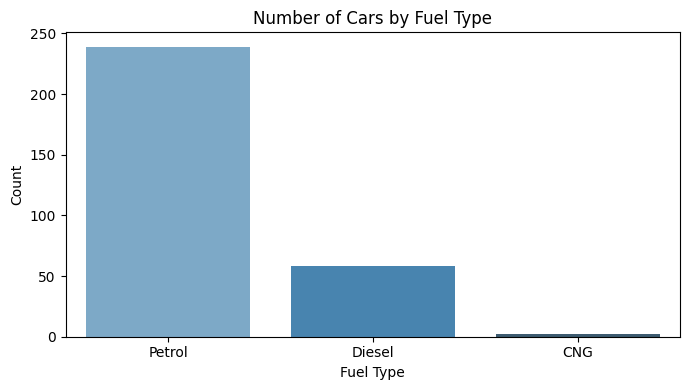

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Fuel_Type', palette='Blues_d')
plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3804/1677214672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fuel_Type', y='Selling_Price', estimator='mean', palette='Blues_d')


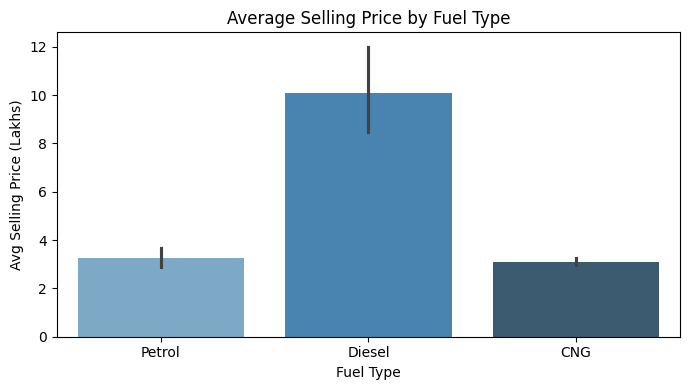

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x='Fuel_Type', y='Selling_Price', estimator='mean', palette='Blues_d')
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Avg Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

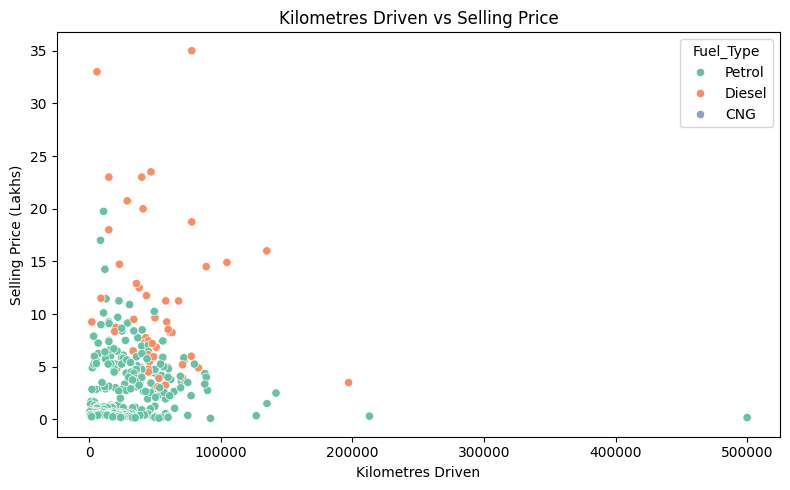

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', hue='Fuel_Type', palette='Set2')
plt.title('Kilometres Driven vs Selling Price')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3804/1853608246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Transmission', y='Selling_Price', palette='Blues')


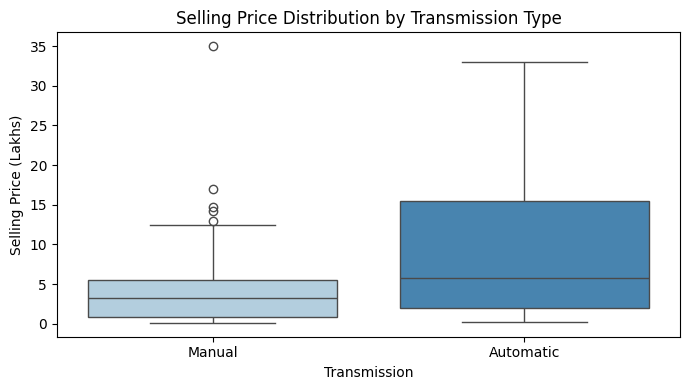

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Transmission', y='Selling_Price', palette='Blues')
plt.title('Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

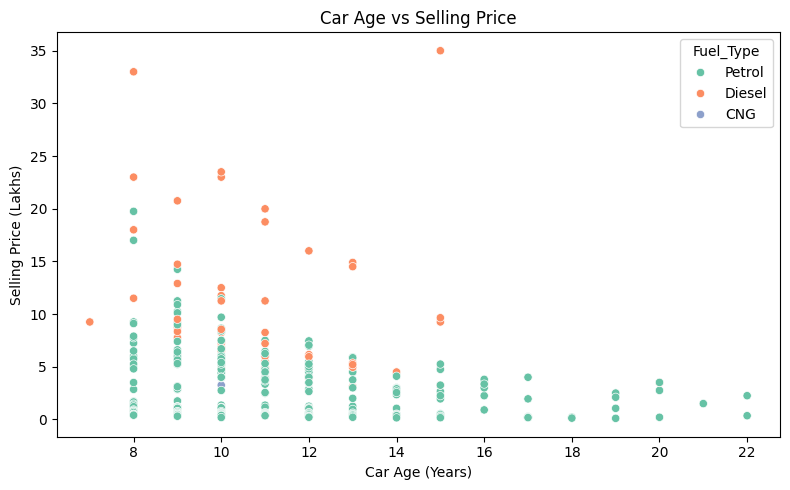

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Fuel_Type', palette='Set2')
plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3804/3554430342.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', palette='Blues_d', ax=axes[0,0])
/tmp/ipykernel_3804/3554430342.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fuel_Type', y='Selling_Price', estimator='mean', palette='Blues_d', ax=axes[0,1])
/tmp/ipykernel_3804/3554430342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Transmission', y='Selling_Price', palette='Blues', ax=axes[1,0])
/tmp/ipykernel_3804/3554430342.py:35: FutureWarning: 

Passing `pa

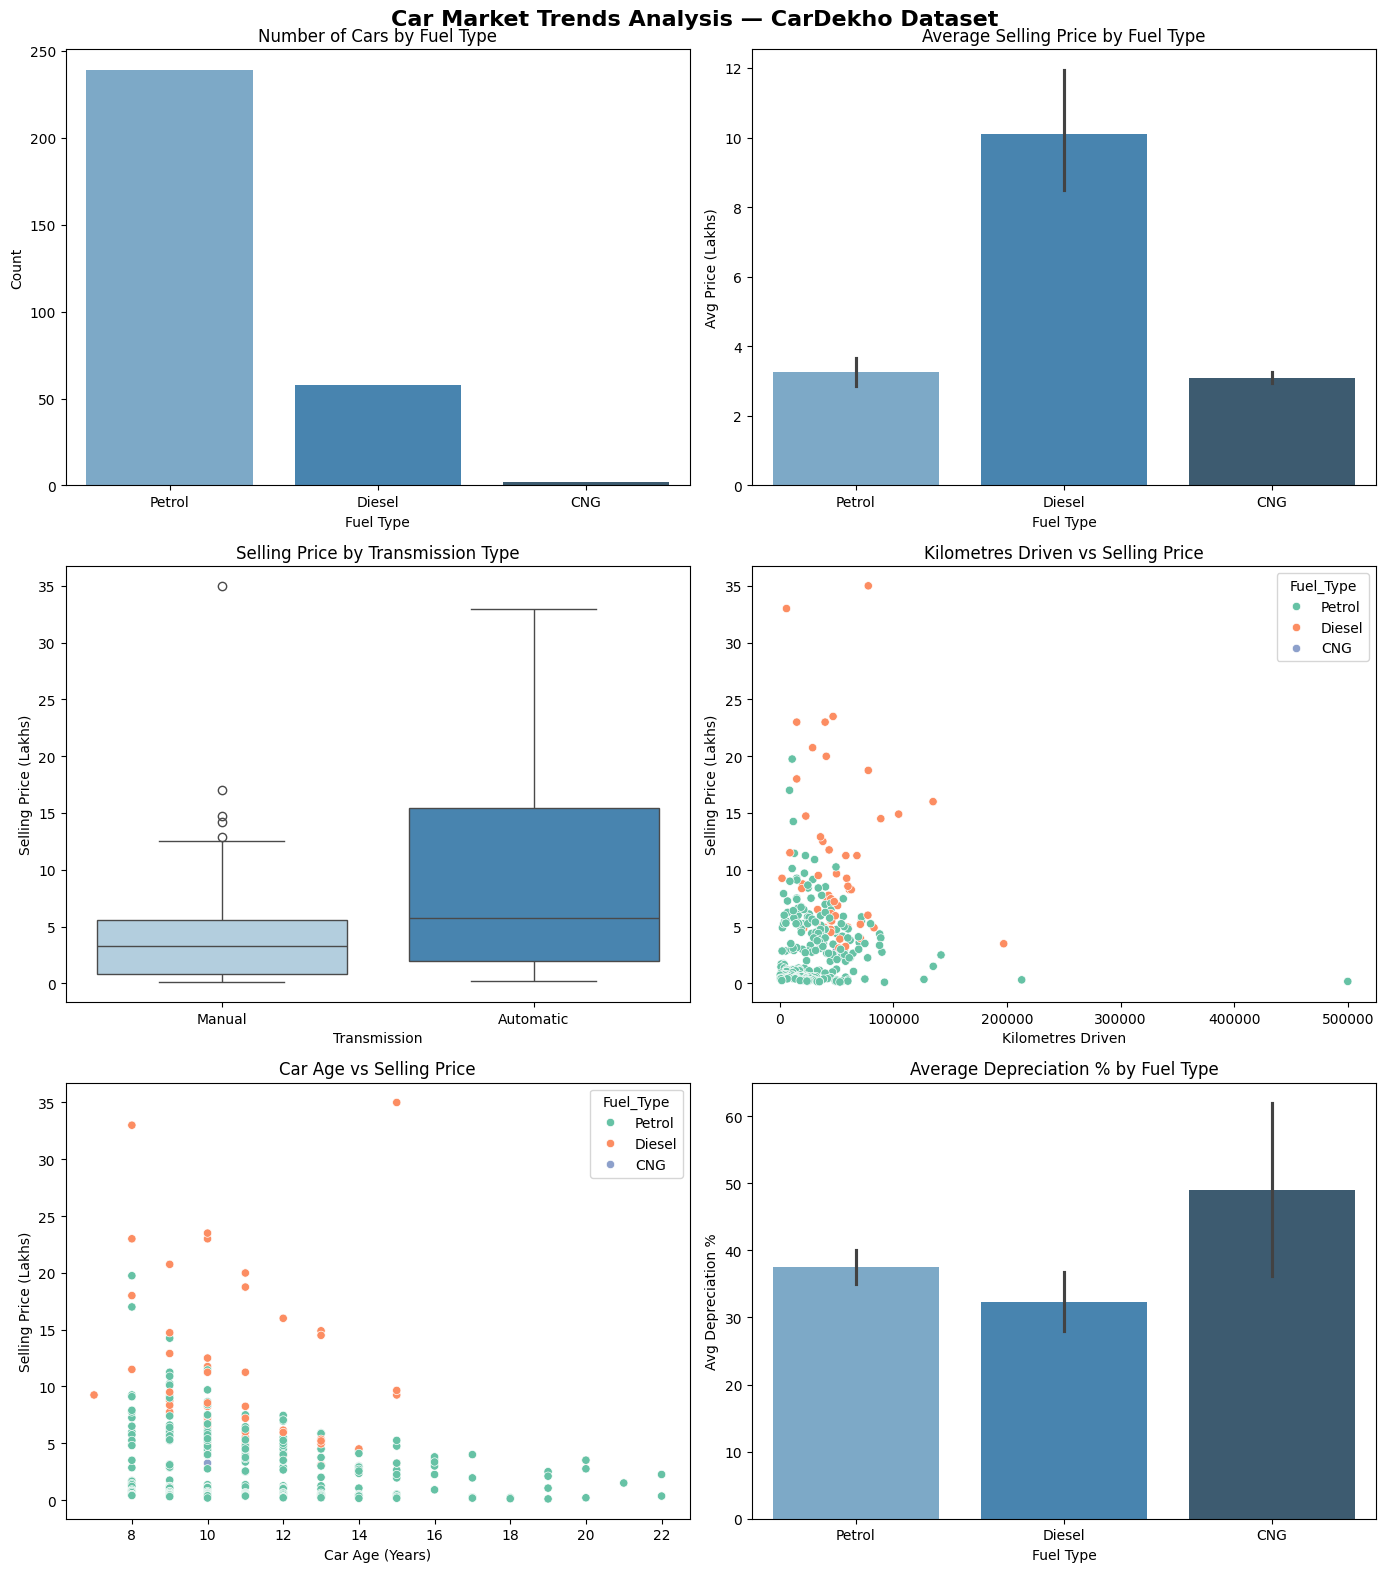

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Car Market Trends Analysis — CarDekho Dataset', fontsize=16, fontweight='bold')

# Chart 1: Cars by Fuel Type
sns.countplot(data=df, x='Fuel_Type', palette='Blues_d', ax=axes[0,0])
axes[0,0].set_title('Number of Cars by Fuel Type')
axes[0,0].set_xlabel('Fuel Type')
axes[0,0].set_ylabel('Count')

# Chart 2: Avg Selling Price by Fuel Type
sns.barplot(data=df, x='Fuel_Type', y='Selling_Price', estimator='mean', palette='Blues_d', ax=axes[0,1])
axes[0,1].set_title('Average Selling Price by Fuel Type')
axes[0,1].set_xlabel('Fuel Type')
axes[0,1].set_ylabel('Avg Price (Lakhs)')

# Chart 3: Selling Price by Transmission
sns.boxplot(data=df, x='Transmission', y='Selling_Price', palette='Blues', ax=axes[1,0])
axes[1,0].set_title('Selling Price by Transmission Type')
axes[1,0].set_xlabel('Transmission')
axes[1,0].set_ylabel('Selling Price (Lakhs)')

# Chart 4: Kms Driven vs Selling Price
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', hue='Fuel_Type', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Kilometres Driven vs Selling Price')
axes[1,1].set_xlabel('Kilometres Driven')
axes[1,1].set_ylabel('Selling Price (Lakhs)')

# Chart 5: Car Age vs Selling Price
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Fuel_Type', palette='Set2', ax=axes[2,0])
axes[2,0].set_title('Car Age vs Selling Price')
axes[2,0].set_xlabel('Car Age (Years)')
axes[2,0].set_ylabel('Selling Price (Lakhs)')

# Chart 6: Depreciation by Fuel Type
sns.barplot(data=df, x='Fuel_Type', y='Depreciation_%', estimator='mean', palette='Blues_d', ax=axes[2,1])
axes[2,1].set_title('Average Depreciation % by Fuel Type')
axes[2,1].set_xlabel('Fuel Type')
axes[2,1].set_ylabel('Avg Depreciation %')

plt.tight_layout()
plt.show()

## Conclusion

This analysis of 299 used car listings from CarDekho reveals that fuel type,
transmission, and car age are the strongest indicators of resale value in the
used car market. Diesel and Automatic vehicles command significantly higher
prices, while CNG vehicles lose value fastest. Buyers seeking value retention
should prioritise newer Diesel or Automatic cars with lower mileage.

These findings can support pricing strategy decisions for used car dealers
and inform buyers about fair market value based on car characteristics.